## Google Drive のマウント
Colab で実行する場合、以下のセルを実行して Google Drive をマウントし、データファイルにアクセスできるようにしてください。ローカル環境の場合はスキップして構いません。

In [28]:
# Google Drive を Colab にマウント
# Colab でのみ必要。ローカル環境や他のプラットフォームでは実行しないでください。
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    # 例: 作業ディレクトリを提出フォルダとしてMyDrive直下にコピーした場合、下記により作業ディレクトリを移動
    %cd /content/drive/MyDrive/提出フォルダ
except ModuleNotFoundError:
    print("google.colab ランタイムではないため、Drive マウントをスキップします。")


google.colab ランタイムではないため、Drive マウントをスキップします。


# 2025年度 採用課題: 表情推定によるマーケティング調査

このノートブックでは、**`smile_predict`** 関数の実装および評価用スケルトンのみを用意しています。  
以下のセルをベースに、自由に追加セルを作成して実験・検証を行ってください。

---

### TODO
- `smile_predict` を実装して笑顔判定ロジックを完成させる  
- 評価セルを実行し **Train / Test accuracy** を確認する

※注意：実行はこのipynbファイルだけで完結する形にしてください。

（学習済みモデルを外部へ一時的に保存して、再度参照等は×）



In [30]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load dataset
data_path = Path('data') / 'facial_keypoints.json'
with open(data_path, 'r', encoding='utf-8') as fp:
    data = json.load(fp)

train = data['train']
test = data['test']

# Basic statistics
print(f"Train samples: {len(train)}")
print(f"Test samples:  {len(test)}")

train_smile     = sum(1 for s in train if s[-1]['smile'])
train_not_smile = len(train) - train_smile
test_smile      = sum(1 for s in test if s[-1]['smile'])
test_not_smile  = len(test) - test_smile

print(f"\nTrain - smile: {train_smile}, not smile: {train_not_smile}")
print(f"Test  - smile: {test_smile},  not smile: {test_not_smile}")

Train samples: 657
Test samples:  282

Train - smile: 302, not smile: 355
Test  - smile: 153,  not smile: 129


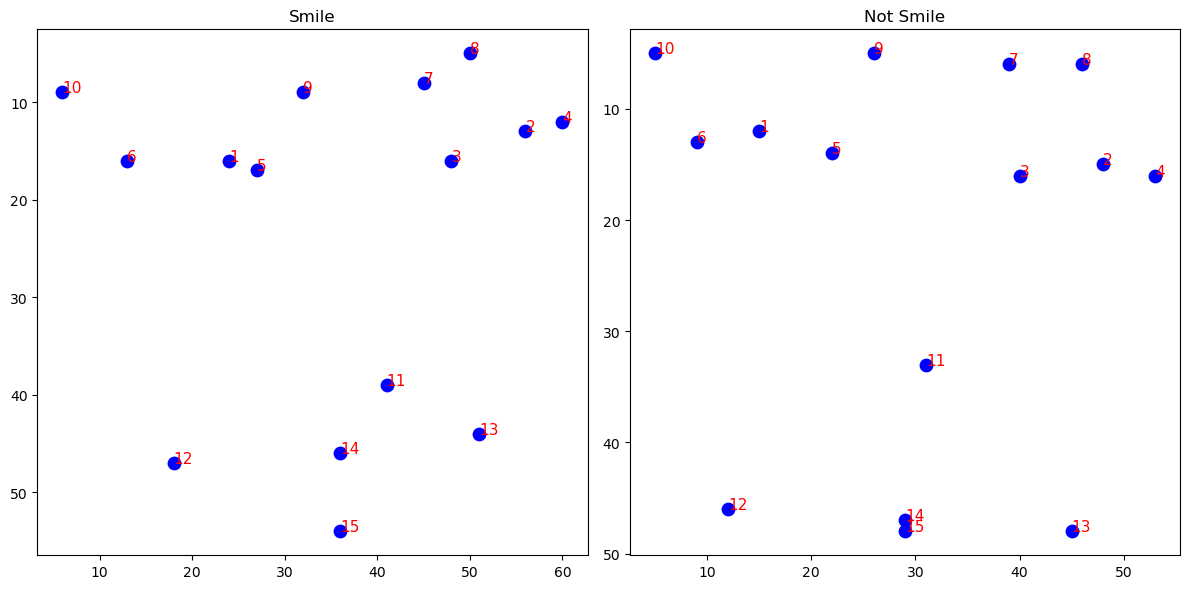

In [31]:
# Pick one smile and one not-smile sample
smile_sample     = [s for s in train if s[-1]['smile']][0]
not_smile_sample = [s for s in train if not s[-1]['smile']][0]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, sample, title in zip(
    axes,
    [smile_sample, not_smile_sample],
    ['Smile', 'Not Smile']
):
    points = sample[1:-1]
    x = [p[0] for p in points]
    y = [p[1] for p in points]
    ax.scatter(x, y, color='blue', s=80)
    for i, (xi, yi) in enumerate(zip(x, y), start=1):
        ax.annotate(str(i), (xi, yi), fontsize=11, color='red')
    ax.invert_yaxis()
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [32]:
# Extract coordinates from all training samples
smile_arr     = np.array([s[1:-1] for s in train if s[-1]['smile']])
not_smile_arr = np.array([s[1:-1] for s in train if not s[-1]['smile']])

# Compare average y value per keypoint between smile and not-smile
print("Keypoint | Smile y_mean | Not-Smile y_mean | Difference")
print("-" * 55)
for i in range(15):
    sy   = smile_arr[:, i, 1].mean()
    ny   = not_smile_arr[:, i, 1].mean()
    diff = sy - ny
    print(f"  Point {i+1:2d} |    {sy:6.2f}    |      {ny:6.2f}      |  {diff:+.2f}")

Keypoint | Smile y_mean | Not-Smile y_mean | Difference
-------------------------------------------------------
  Point  1 |     15.12    |       15.12      |  -0.00
  Point  2 |     14.82    |       14.54      |  +0.28
  Point  3 |     16.14    |       15.84      |  +0.30
  Point  4 |     15.13    |       14.83      |  +0.30
  Point  5 |     16.25    |       16.10      |  +0.14
  Point  6 |     15.51    |       15.63      |  -0.12
  Point  7 |      6.05    |        5.88      |  +0.17
  Point  8 |      4.96    |        4.91      |  +0.04
  Point  9 |      6.32    |        6.15      |  +0.17
  Point 10 |      8.51    |        8.81      |  -0.30
  Point 11 |     35.39    |       34.98      |  +0.41
  Point 12 |     46.02    |       47.96      |  -1.94
  Point 13 |     45.46    |       47.34      |  -1.88
  Point 14 |     46.06    |       49.06      |  -3.00
  Point 15 |     52.51    |       50.03      |  +2.48


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Extract features from mouth region (points 11-15)
def extract_features_A(sample):
    points = sample[1:-1]
    mouth = points[10:15]  # points 11-15
    return [coord for p in mouth for coord in p]  # flatten to 10 numbers

# Prepare data
X_train_A = [extract_features_A(s) for s in train]
X_test_A  = [extract_features_A(s) for s in test]
y_train   = [s[-1]['smile'] for s in train]
y_test    = [s[-1]['smile'] for s in test]

# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC()
}

# Train and evaluate each model
print("=== Plan A: Mouth Region (Points 11-15) ===")
print(f"{'Model':<22} {'Train':>6}  {'Test':>6}")
print("-" * 38)
for name, model in models.items():
    model.fit(X_train_A, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_A))
    test_acc  = accuracy_score(y_test,  model.predict(X_test_A))
    print(f"{name:<22} {train_acc:.3f}   {test_acc:.3f}")

=== Plan A: Mouth Region (Points 11-15) ===
Model                   Train    Test
--------------------------------------
Logistic Regression    0.933   0.933
Decision Tree          1.000   0.816
Random Forest          1.000   0.922
SVM                    0.939   0.936


In [34]:
# Extract all 15 keypoints as features
def extract_features_B(sample):
    points = sample[1:-1]
    return [coord for p in points for coord in p]  # flatten to 30 numbers

# Prepare data
X_train_B = [extract_features_B(s) for s in train]
X_test_B  = [extract_features_B(s) for s in test]

# Train and evaluate each model
print("=== Plan B: All Keypoints (Points 1-15) ===")
print(f"{'Model':<22} {'Train':>6}  {'Test':>6}")
print("-" * 38)
for name, model in models.items():
    model.fit(X_train_B, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_B))
    test_acc  = accuracy_score(y_test,  model.predict(X_test_B))
    print(f"{name:<22} {train_acc:.3f}   {test_acc:.3f}")

=== Plan B: All Keypoints (Points 1-15) ===
Model                   Train    Test
--------------------------------------
Logistic Regression    0.941   0.943
Decision Tree          1.000   0.819
Random Forest          1.000   0.915
SVM                    0.932   0.922


In [35]:
from __future__ import annotations
import json
from pathlib import Path
from sklearn.linear_model import LogisticRegression

# Load training data
data_path = Path('data') / 'facial_keypoints.json'
with open(data_path, 'r', encoding='utf-8') as fp:
    _data = json.load(fp)

# Flatten all 15 keypoints into 30 features (Plan B)
def _extract_features(sample):
    points = sample[1:-1]
    return [coord for p in points for coord in p]

# Train Logistic Regression on training data
_X_train = [_extract_features(s) for s in _data['train']]
_y_train = [s[-1]['smile'] for s in _data['train']]
_model = LogisticRegression(max_iter=1000)
_model.fit(_X_train, _y_train)

# smile_predict を実装して笑顔判定ロジックを完成させる
def smile_predict(facial_data: list) -> bool:
    """Return True if the facial data is classified as smiling.

    Parameters
    ----------
    facial_data : list
        ["sampleID", [x1,y1], [x2,y2], ..., [x15,y15]]

    Returns
    -------
    bool
        True  → smiling
        False → not smiling
    """
    # Extract 30 features from all 15 keypoints
    features = [coord for p in facial_data[1:] for coord in p]

    # Predict using trained model (Plan B + Logistic Regression, Test acc: 94.3%)
    return bool(_model.predict([features])[0])

In [36]:
# --- 動作確認: pred vs ground truth を文字列で表示（編集不要） -------------------------
import json
from pathlib import Path

# データセットのロード
data_path = Path('data') / 'facial_keypoints.json'
with open(data_path, 'r', encoding='utf-8') as fp:
    data = json.load(fp)

test = data['test']

print("=== Test Data Predictions vs Ground Truth ===")
for idx, sample in enumerate(test, start=1):
    face_input = sample[:-1]  # 最後のsmileオブジェクトを除いたデータ
    gt_bool = sample[-1]['smile']
    pred_bool = smile_predict(face_input)

    # ブールを文字列に変換
    gt = 'smile' if gt_bool else 'not smile'
    pred = 'smile' if pred_bool else 'not smile'

    print(f"[{idx:03d}] Input ID: {face_input[0]} → Pred: {pred} , GT: {gt}")


=== Test Data Predictions vs Ground Truth ===
[001] Input ID: el0etgO0lV → Pred: not smile , GT: not smile
[002] Input ID: t0eKPqRqap → Pred: not smile , GT: not smile
[003] Input ID: Y5crMjuXoD → Pred: smile , GT: smile
[004] Input ID: 6ED4JFqQT4 → Pred: smile , GT: not smile
[005] Input ID: uXGZOKRlG4 → Pred: not smile , GT: smile
[006] Input ID: sCTN8vfQCl → Pred: smile , GT: smile
[007] Input ID: HHJILic8r7 → Pred: smile , GT: smile
[008] Input ID: Ye6cD5YaiK → Pred: smile , GT: smile
[009] Input ID: vNSHMaCjlj → Pred: smile , GT: smile
[010] Input ID: 3M41I4E9pY → Pred: not smile , GT: not smile
[011] Input ID: ND2YcZbnys → Pred: smile , GT: smile
[012] Input ID: s0m8aGw7GA → Pred: smile , GT: smile
[013] Input ID: RnRlzWyOrW → Pred: smile , GT: smile
[014] Input ID: 5wtUnKT6dh → Pred: smile , GT: smile
[015] Input ID: f3iqR2cuxe → Pred: smile , GT: smile
[016] Input ID: SwZ2RR93rY → Pred: not smile , GT: not smile
[017] Input ID: bwycl8uaqI → Pred: smile , GT: smile
[018] Input I

In [37]:
# 評価セルを実行し Train / Test accuracy を確認する
# Evaluate final model accuracy on train and test set
from sklearn.metrics import accuracy_score

X_test_final  = [_extract_features(s) for s in _data['test']]
y_test_final  = [s[-1]['smile'] for s in _data['test']]

train_acc = accuracy_score(_y_train, _model.predict(_X_train))
test_acc  = accuracy_score(y_test_final, _model.predict(X_test_final))

print("=== Final Model Evaluation ===")
print(f"Model          : Logistic Regression (Plan B - All 15 Keypoints)")
print(f"Train Accuracy : {train_acc:.3f}")
print(f"Test  Accuracy : {test_acc:.3f}")

=== Final Model Evaluation ===
Model          : Logistic Regression (Plan B - All 15 Keypoints)
Train Accuracy : 0.941
Test  Accuracy : 0.943


---

## 次のステップ
1. (optional)上記の `smile_predict` を改良し、ビジネス要件（軽量・高速）を満たしつつ精度を高めてください  
2. 上記分析の結果を、`smile_detection_report.pdf` としてレポートにまとめましょう。
3. 上記の`smile_detection_report.pdf`と こちらの**`coding_test_smile_detection.ipynb`** を共有リンク内の提出フォルダへ配置し、メールにてご一報いただければと思います。
